In [ ]:
# ============================================================================
# SETUP
# ============================================================================

!pip install -q sentence-transformers spacy textstat joblib scikit-learn beautifulsoup4
!python -m spacy download en_core_web_sm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import os, re, string, random, joblib
from collections import defaultdict, Counter
from tqdm import tqdm
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, train_test_split
from scipy.spatial.distance import pdist
import spacy, textstat
from bs4 import BeautifulSoup
from sentence_transformers import SentenceTransformer
!pip install -U sentence-transformers


from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = "/content/drive/MyDrive/final_year_project_books_folder"
BOOKS_DIR = os.path.join(DRIVE_ROOT, "gutenberg_books")
CACHE_DIR = os.path.join(DRIVE_ROOT, "feat_cache")
CKPT_DIR = os.path.join(DRIVE_ROOT, "vades_final_rebuild")
SPLIT_DIR = os.path.join(DRIVE_ROOT, "splits_final")
OUTPUT_CSV = os.path.join(DRIVE_ROOT, "gutenberg_dataset_clean.csv")

for d in [CACHE_DIR, CKPT_DIR, SPLIT_DIR]:
    os.makedirs(d, exist_ok=True)

RND = 42
random.seed(RND)
np.random.seed(RND)
torch.manual_seed(RND)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ============================================================================
# DATA LOADING (WITH CACHING)
# ============================================================================

def extract_text_from_html(path):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        soup = BeautifulSoup(f, "html.parser")
        for tag in soup(["table", "script", "style"]): tag.extract()
        return soup.get_text(separator=" ", strip=True)

def clean_gutenberg_text(text):
    text = re.sub(r'(?is).*?(the project gutenberg ebook of )', '', text, count=1)
    text = re.sub(r'(?is)end of (the )?project gutenberg ebook.*', '', text)
    text = re.sub(r'(?is)\*\*\*.*?project gutenberg.*?\*\*\*', '', text)
    text = re.sub(r'(?i)(produced by|transcribed from).*?\n', '', text)
    text = re.sub(r'\b(CHAPTER|Chapter)\s+[A-Z0-9IVX]+\b', '', text)
    text = re.sub(r'[_*#~-]{2,}', ' ', text)
    text = re.sub(r'http\S+', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def chunk_text(text, size=4000, overlap=500):
    chunks, start = [], 0
    while start < len(text):
        chunks.append(text[start:start+size])
        start += size - overlap
    return chunks

if os.path.exists(OUTPUT_CSV):
    df = pd.read_csv(OUTPUT_CSV)
    print(f"✓ Loaded {len(df)} chunks")
else:
    data = []
    for author in tqdm(os.listdir(BOOKS_DIR)):
        folder = os.path.join(BOOKS_DIR, author)
        if not os.path.isdir(folder): continue
        for fname in os.listdir(folder):
            if not fname.endswith(".html"): continue
            try:
                raw = extract_text_from_html(os.path.join(folder, fname))
                clean = clean_gutenberg_text(raw)
                for chunk in chunk_text(clean):
                    if chunk.strip():
                        data.append({"author": author, "file_name": fname, "text": chunk})
            except: pass
    df = pd.DataFrame(data)
    df.to_csv(OUTPUT_CSV, index=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Mounted at /content/drive
Device: cuda
✓ Loaded 15198 chunks


In [ ]:
!pip install tensorflow tensorflow-hub tensorflow-text --quiet

In [ ]:
# ============================================================================
# BOOK-LEVEL SPLIT (NO DATA LEAKAGE)
# ============================================================================

train_csv, val_csv, test_csv = [os.path.join(SPLIT_DIR, f"{s}.csv") for s in ["train", "val", "test"]]

if all(os.path.exists(f) for f in [train_csv, val_csv, test_csv]):
    train_df, val_df, test_df = pd.read_csv(train_csv), pd.read_csv(val_csv), pd.read_csv(test_csv)
    print(f"✓ Loaded splits")
else:
    df['book_id'] = df['author'] + '___' + df['file_name']
    books = df[['author', 'book_id']].drop_duplicates()

    train_books, temp = train_test_split(books, test_size=0.3, stratify=books['author'], random_state=RND)
    val_books, test_books = train_test_split(temp, test_size=0.5, stratify=temp['author'], random_state=RND)

    train_df = df[df['book_id'].isin(train_books['book_id'])].reset_index(drop=True)
    val_df = df[df['book_id'].isin(val_books['book_id'])].reset_index(drop=True)
    test_df = df[df['book_id'].isin(test_books['book_id'])].reset_index(drop=True)

    # Verify no leakage
    assert len(set(train_df['book_id']) & set(test_df['book_id'])) == 0

    train_df.to_csv(train_csv, index=False)
    val_df.to_csv(val_csv, index=False)
    test_df.to_csv(test_csv, index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

✓ Loaded splits
Train: 10809, Val: 2454, Test: 1935


In [ ]:
# ============================================================================
# STYLE FEATURES (300-D, WITH CACHING)
# ============================================================================

import tensorflow_hub as hub
import numpy as np
import joblib
import re, string
from collections import Counter
from tqdm import tqdm
import textstat
import spacy
import os

# Load spaCy
nlp = spacy.load("en_core_web_sm", disable=["parser"])

# Function words
FUNCTION_WORDS = ["the","be","to","of","and","a","in","that","have","i","it","for","not",
                  "on","with","he","as","you","do","at","this","but","his","by","from",
                  "they","we","say","her","she","or","an","will","my","one","all","would",
                  "there","their","what","so","up","out","if","about","who","get","which",
                  "go","me","when","make","can","like","time","no","just","him","know","take"]


# -----------------------------
# STYLE FEATURE VECTOR (unchanged)
# -----------------------------
def build_style_vector(text, dim=300):
    feats = []
    words = text.split()
    nw = len(words)

    # Basic (5)
    feats += [len(text), nw, max(1, len(re.split(r'[.!?]+', text))),
              nw/max(1,len(re.split(r'[.!?]+',text))),
              sum(len(w) for w in words)/max(1,nw)]

    # Punctuation (11)
    punc_counts = Counter(ch for ch in text if ch in string.punctuation)
    for k in ['.',',',';','!','?',"'",'"',':','-','(',')']:
        feats.append(punc_counts.get(k,0)/max(1,nw))

    # Function words (60)
    word_lower = [w.lower() for w in re.findall(r"\w+", text)]
    wc = Counter(word_lower)
    feats += [wc.get(fw,0)/max(1,len(word_lower)) for fw in FUNCTION_WORDS[:60]]

    # Lexical (3)
    types = set(word_lower)
    feats += [
        len(types)/max(1,len(word_lower)),
        sum(1 for _, c in wc.items() if c == 1)/max(1,nw),
        0.0
    ]

    # Syllables (2)
    try:
        sylls = textstat.syllable_count(text)
    except:
        sylls = sum(max(1, sum(1 for c in w if c.lower() in 'aeiou')) for w in words)
    feats += [sylls, sylls/max(1,nw)]

    # Readability (4)
    try:
        feats += [
            textstat.flesch_reading_ease(text),
            textstat.flesch_kincaid_grade(text),
            textstat.smog_index(text),
            textstat.coleman_liau_index(text)
        ]
    except:
        feats += [0.0] * 4

    # POS + NER (28)
    doc = nlp(text)
    pos_c = Counter(t.pos_ for t in doc)
    ner_c = Counter(e.label_ for e in doc.ents)

    for k in ['NOUN','VERB','ADJ','ADV','PRON','DET','ADP','NUM','PROPN',
              'PART','INTJ','SYM','X','PUNCT']:
        feats.append(pos_c.get(k,0)/max(1,len(doc)))

    for k in ['PERSON','NORP','ORG','GPE','LOC','PRODUCT','EVENT','WORK_OF_ART',
              'LAW','LANGUAGE','DATE','TIME','PERCENT','MONEY']:
        feats.append(ner_c.get(k,0)/max(1,len(doc)))

    # Char n-grams (50)
    s = re.sub(r'\s+','',text.lower())
    char_ng = Counter()
    for n in [2,3,4]:
        for i in range(len(s)-n+1):
            char_ng[s[i:i+n]] += 1

    top = [g for g,_ in char_ng.most_common(50)]
    tot = max(1, sum(char_ng.values()))
    feats += [char_ng.get(g,0)/tot for g in top]
    if len(feats) < 85 + 50:
        feats += [0.0] * (85 + 50 - len(feats))

    # Word bigrams (50)
    word_bg = Counter()
    for i in range(len(word_lower)-1):
        word_bg[" ".join(word_lower[i:i+2])] += 1
    top = [g for g,_ in word_bg.most_common(50)]
    tot = max(1, sum(word_bg.values()))
    feats += [word_bg.get(g,0)/tot for g in top]
    if len(feats) < 185:
        feats += [0.0] * (185 - len(feats))

    # Distributional (2)
    probs = np.array([v/max(1,sum(wc.values())) for v in wc.values()], dtype=float)
    feats += [
        -np.sum(probs*np.log2(probs+1e-12)),
        max(wc.values())/max(1,sum(wc.values())) if wc else 0.0
    ]

    # Extra (3)
    feats += [
        sum(1 for c in text if c.isdigit())/max(1,len(text)),
        sum(1 for w in words if w.isupper())/max(1,nw),
        sum(1 for w in word_lower if w in spacy.lang.en.stop_words.STOP_WORDS)/max(1,len(word_lower))
    ]

    feats = feats[:dim] + [0.0]*(dim - len(feats))
    return np.array(feats, dtype=np.float32)


# -----------------------------
# FEATURE CACHING
# -----------------------------
def cache_features(df, path):
    if os.path.exists(path):
        print(f"✓ Loading {os.path.basename(path)}")
        return joblib.load(path)
    feats = [build_style_vector(t) for t in tqdm(df['text'], desc="Features")]
    joblib.dump(np.stack(feats), path)
    return np.stack(feats)


train_feats = cache_features(train_df, os.path.join(CACHE_DIR, "train_feats_rebuild.joblib"))
val_feats   = cache_features(val_df,   os.path.join(CACHE_DIR, "val_feats_rebuild.joblib"))
test_feats  = cache_features(test_df,  os.path.join(CACHE_DIR, "test_feats_rebuild.joblib"))


# ============================================================================
# EMBEDDINGS - UPDATED TO USE UNIVERSAL SENTENCE ENCODER (USE)
# ============================================================================

print("\nLoading Universal Sentence Encoder (USE)...")
use_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print("✓ USE loaded successfully (512-dimensional output).")


def cache_USE_embeddings(df, path, batch_size=64):
    if os.path.exists(path):
        print(f"✓ Loading {os.path.basename(path)}")
        return joblib.load(path)

    texts = df['text'].tolist()
    all_embs = []

    print(f"Computing USE embeddings for {len(texts)} samples...")
    for i in tqdm(range(0, len(texts), batch_size), desc="USE Embeddings"):
        batch = texts[i:i+batch_size]
        emb = use_model(batch).numpy()   # 512-D output
        all_embs.append(emb)

    all_embs = np.vstack(all_embs)
    joblib.dump(all_embs, path)
    return all_embs


train_embs = cache_USE_embeddings(train_df, os.path.join(CACHE_DIR, "train_use_embs.joblib"))
val_embs   = cache_USE_embeddings(val_df,   os.path.join(CACHE_DIR, "val_use_embs.joblib"))
test_embs  = cache_USE_embeddings(test_df,  os.path.join(CACHE_DIR, "test_use_embs.joblib"))

print(f"Features: {train_feats.shape}, USE Embeddings: {train_embs.shape}")


✓ Loading train_feats_rebuild.joblib
✓ Loading val_feats_rebuild.joblib
✓ Loading test_feats_rebuild.joblib

Loading Universal Sentence Encoder (USE)...
✓ USE loaded successfully (512-dimensional output).
✓ Loading train_use_embs.joblib
✓ Loading val_use_embs.joblib
✓ Loading test_use_embs.joblib
Features: (10809, 300), USE Embeddings: (10809, 512)


In [ ]:
# =====================================================================
# SCALE STYLE FEATURES (FIT ON TRAIN ONLY)
# =====================================================================

style_mean = train_feats.mean(axis=0)
style_std  = train_feats.std(axis=0)
style_std[style_std == 0] = 1.0  # prevent division by zero

def scale_feats(X):
    return ((X - style_mean) / style_std).astype(np.float32)

# Apply scaling
train_feats = scale_feats(train_feats)
val_feats   = scale_feats(val_feats)
test_feats  = scale_feats(test_feats)

print("✓ Style features scaled")
print("train_feats:", train_feats.shape)
print("val_feats:",   val_feats.shape)
print("test_feats:",  test_feats.shape)


✓ Style features scaled
train_feats: (10809, 300)
val_feats: (2454, 300)
test_feats: (1935, 300)


In [ ]:
joblib.dump(
    {"mean": style_mean, "std": style_std},
    os.path.join(CACHE_DIR, "style_scaler.joblib")
)
print("✓ Style scaler saved")


✓ Style scaler saved


In [ ]:
# Create author -> integer ID mapping
authors = sorted(pd.concat([train_df['author'], val_df['author'], test_df['author']]).unique())
author2id = {a: i for i, a in enumerate(authors)}
id2author = {i: a for a, i in author2id.items()}

num_authors = len(author2id)
print("Number of authors:", num_authors)


Number of authors: 10


In [ ]:
train_df['author_id'] = train_df['author'].map(author2id)
val_df['author_id']   = val_df['author'].map(author2id)
test_df['author_id']  = test_df['author'].map(author2id)

# Sanity check
print(train_df[['author', 'author_id']])


                   author  author_id
0             Oscar Wilde          9
1             Oscar Wilde          9
2             Oscar Wilde          9
3             Oscar Wilde          9
4             Oscar Wilde          9
...                   ...        ...
10804  Arthur Conan Doyle          0
10805  Arthur Conan Doyle          0
10806  Arthur Conan Doyle          0
10807  Arthur Conan Doyle          0
10808  Arthur Conan Doyle          0

[10809 rows x 2 columns]


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VADES_Fuse(nn.Module):
    def __init__(self, use_dim=512, style_in_dim=300, out_dim=300, hidden=1024, n_authors=10, dropout=0.5):
        """
        use_dim: dimension of USE input (512)
        style_in_dim: dimension of handcrafted style vector (e.g. 300)
        out_dim: output embedding dimension (final doc embedding)
        """
        super().__init__()
        self.input_dim = use_dim + style_in_dim
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, out_dim)
        )
        self.authors = nn.Embedding(n_authors, out_dim)
        nn.init.xavier_uniform_(self.authors.weight)

    def forward(self, use_emb, style_feat):
        """
        use_emb: [B, use_dim], style_feat: [B, style_in_dim]
        returns: [B, out_dim]
        """
        if use_emb.dim() == 1:
            use_emb = use_emb.unsqueeze(0)
        if style_feat.dim() == 1:
            style_feat = style_feat.unsqueeze(0)
        x = torch.cat([use_emb, style_feat], dim=1)
        return self.encoder(x)

    def get_document_embedding(self, use_emb, style_feat):
        return self.forward(use_emb, style_feat)


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32
NUM_WORKERS = 2  # set 0 if Colab complains

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("✓ DataLoaders created")
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))


✓ DataLoaders created
Train batches: 337
Val batches: 77
Test batches: 61


In [ ]:
class DocDataset(Dataset):
    def __init__(self, embs, feats, author_ids):
        self.embs = embs
        self.feats = feats
        self.author_ids = author_ids

    def __len__(self):
        return len(self.embs)

    def __getitem__(self, i):
        return (
            torch.tensor(self.embs[i], dtype=torch.float32),
            torch.tensor(self.feats[i], dtype=torch.float32),
            torch.tensor(self.author_ids[i], dtype=torch.long)
        )


In [ ]:
train_ds = DocDataset(train_embs, train_feats, train_df['author_id'].values)
val_ds   = DocDataset(val_embs,   val_feats,   val_df['author_id'].values)
test_ds  = DocDataset(test_embs,  test_feats,  test_df['author_id'].values)


In [ ]:
import torch.nn.functional as F

def contrastive_cosine_loss(model, use_emb, style_feat, author_ids, neg_author_ids, neg_style_feats, margin=0.2, alpha=0.8):
    """
    - use_emb: [B, use_dim]
    - style_feat: [B, style_in_dim]  (already scaled)
    - neg_author_ids: [B, K]
    - neg_style_feats: [B, K, style_in_dim]
    """
    doc_out = model(use_emb, style_feat)            # [B, out_dim]
    doc_n = F.normalize(doc_out, dim=1)             # normalized

    # positive authors and positive style
    pos_author_emb = model.authors(author_ids)      # [B, out_dim]
    pos_author_n = F.normalize(pos_author_emb, dim=1)
    pos_style_n = F.normalize(style_feat, dim=1)    # projecting style features into unit sphere

    pos_sim_author = (doc_n * pos_author_n).sum(dim=1)   # [B]
    pos_sim_style = (doc_n * pos_style_n).sum(dim=1)     # [B]

    # negative author embeddings
    B, K = neg_author_ids.shape
    neg_author_emb = model.authors(neg_author_ids.view(-1)).view(B, K, -1)  # [B,K,D]
    neg_author_n = F.normalize(neg_author_emb, dim=2)                       # [B,K,D]
    neg_style_n = F.normalize(neg_style_feats, dim=2)                       # [B,K,D]

    doc_n_exp = doc_n.unsqueeze(1)  # [B,1,D]
    neg_sim_author = (doc_n_exp * neg_author_n).sum(dim=2)  # [B,K]
    neg_sim_style = (doc_n_exp * neg_style_n).sum(dim=2)    # [B,K]

    # hinge losses: make pos_sim > neg_sim + margin
    author_loss = F.relu(neg_sim_author - pos_sim_author.unsqueeze(1) + margin).mean()
    style_loss = F.relu(neg_sim_style - pos_sim_style.unsqueeze(1) + margin).mean()

    total = (1 - alpha) * author_loss + alpha * style_loss
    return total, author_loss.detach(), style_loss.detach()


In [ ]:
# ----- instantiate model -----
use_dim = train_embs.shape[1]      # 512
style_in_dim = train_feats.shape[1]  # 300

out_dim = 300
hidden = 1024

model = VADES_Fuse(use_dim=use_dim, style_in_dim=style_in_dim, out_dim=out_dim, hidden=hidden, n_authors=num_authors).to(device)

# optimizer and scheduler
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
EPOCHS, ALPHA, MARGIN, K_NEG = 15, 0.8, 0.2, 5

best_val = float('inf')
loss_history = {'train':[], 'val':[], 'author':[], 'style':[]}

for epoch in range(1, EPOCHS+1):
    model.train()
    batch_losses = []
    batch_a_losses = []
    batch_s_losses = []

    for use_emb, style_feat, aid in train_loader:
        use_emb = use_emb.to(device); style_feat = style_feat.to(device); aid = aid.to(device)
        B = use_emb.size(0)

        # negative authors sampling - vectorized & ensure != positive
        neg_aids = torch.randint(0, num_authors, (B, K_NEG), device=device)
        mask = (neg_aids == aid.unsqueeze(1))
        while mask.any():
            neg_aids[mask] = torch.randint(0, num_authors, (mask.sum().item(),), device=device)
            mask = (neg_aids == aid.unsqueeze(1))

        # negative style feats: simple batch-permutation (cheap)
        idx = torch.randperm(B, device=device)
        neg_style = torch.stack([style_feat[idx.roll(i+1)] for i in range(K_NEG)], dim=1)  # [B,K,S]

        loss, a_loss, s_loss = contrastive_cosine_loss(model, use_emb, style_feat, aid, neg_aids, neg_style, margin=MARGIN, alpha=ALPHA)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()

        batch_losses.append(loss.item())
        batch_a_losses.append(a_loss.item())
        batch_s_losses.append(s_loss.item())

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for use_emb, style_feat, aid in val_loader:
            use_emb = use_emb.to(device); style_feat = style_feat.to(device); aid = aid.to(device)
            B = use_emb.size(0)
            neg_aids = torch.randint(0, num_authors, (B, K_NEG), device=device)
            idx = torch.randperm(B, device=device)
            neg_style = torch.stack([style_feat[idx.roll(i+1)] for i in range(K_NEG)], dim=1)
            vloss, _, _ = contrastive_cosine_loss(model, use_emb, style_feat, aid, neg_aids, neg_style, margin=MARGIN, alpha=ALPHA)
            val_losses.append(vloss.item())

    avg_train = float(np.mean(batch_losses))
    avg_val = float(np.mean(val_losses))
    avg_a = float(np.mean(batch_a_losses)) if batch_a_losses else 0.0
    avg_s = float(np.mean(batch_s_losses)) if batch_s_losses else 0.0

    loss_history['train'].append(avg_train)
    loss_history['val'].append(avg_val)
    loss_history['author'].append(avg_a)
    loss_history['style'].append(avg_s)

    print(f"[Epoch {epoch}/{EPOCHS}] train={avg_train:.4f} val={avg_val:.4f} author={avg_a:.4f} style={avg_s:.4f}")
    scheduler.step(avg_val)

    if avg_val < best_val:
        best_val = avg_val
        torch.save(model.state_dict(), os.path.join(CKPT_DIR, "best.pth"))
        print("  -> saved best.pth")


[Epoch 1/15] train=0.0346 val=0.0236 author=0.0788 style=0.0236
  -> saved best.pth
[Epoch 2/15] train=0.0127 val=0.0187 author=0.0306 style=0.0082
  -> saved best.pth
[Epoch 3/15] train=0.0099 val=0.0173 author=0.0207 style=0.0072
  -> saved best.pth
[Epoch 4/15] train=0.0087 val=0.0167 author=0.0158 style=0.0070
  -> saved best.pth
[Epoch 5/15] train=0.0080 val=0.0161 author=0.0125 style=0.0069
  -> saved best.pth
[Epoch 6/15] train=0.0076 val=0.0155 author=0.0107 style=0.0068
  -> saved best.pth
[Epoch 7/15] train=0.0069 val=0.0154 author=0.0092 style=0.0063
  -> saved best.pth
[Epoch 8/15] train=0.0068 val=0.0157 author=0.0080 style=0.0065
[Epoch 9/15] train=0.0063 val=0.0154 author=0.0073 style=0.0061
[Epoch 10/15] train=0.0066 val=0.0145 author=0.0062 style=0.0067
  -> saved best.pth
[Epoch 11/15] train=0.0063 val=0.0148 author=0.0059 style=0.0064
[Epoch 12/15] train=0.0063 val=0.0148 author=0.0050 style=0.0066
[Epoch 13/15] train=0.0060 val=0.0145 author=0.0046 style=0.0063
[Epo

In [ ]:
# =====================================================================
# EXTRACT FINAL DOCUMENT EMBEDDINGS (TRAIN + VAL + TEST)
# =====================================================================

model.eval()

def extract_embeddings(loader):
    embs = []
    with torch.no_grad():
        for use_emb, style_feat, _ in loader:
            use_emb = use_emb.to(device)
            style_feat = style_feat.to(device)
            out = model(use_emb, style_feat)
            out = F.normalize(out, dim=1)  # cosine-ready
            embs.append(out.cpu().numpy())
    return np.vstack(embs)

train_doc_embs = extract_embeddings(train_loader)
val_doc_embs   = extract_embeddings(val_loader)
test_doc_embs  = extract_embeddings(test_loader)

print("Train:", train_doc_embs.shape)
print("Val:  ", val_doc_embs.shape)
print("Test: ", test_doc_embs.shape)


Train: (10784, 300)
Val:   (2454, 300)
Test:  (1935, 300)


In [ ]:
doc_embeddings = np.vstack([train_doc_embs, val_doc_embs, test_doc_embs])
doc_texts = pd.concat([train_df, val_df, test_df])['text'].values
doc_authors = pd.concat([train_df, val_df, test_df])['author'].values

print(doc_embeddings.shape)


(15173, 300)


In [ ]:
# Combine all splits
all_use = np.vstack([train_embs, val_embs, test_embs])
all_style = np.vstack([train_feats, val_feats, test_feats])

print(all_use.shape, all_style.shape)


(15198, 512) (15198, 300)


In [ ]:
model.eval()

all_doc_embeddings = []
BATCH = 256

with torch.no_grad():
    for i in range(0, len(all_use), BATCH):
        use_b = torch.from_numpy(all_use[i:i+BATCH]).float().to(device)
        style_b = torch.from_numpy(all_style[i:i+BATCH]).float().to(device)

        out = model(use_b, style_b)  # [B, 300]
        out = F.normalize(out, dim=1)  # IMPORTANT for cosine similarity

        all_doc_embeddings.append(out.cpu().numpy())

all_doc_embeddings = np.vstack(all_doc_embeddings)

print("Final embeddings:", all_doc_embeddings.shape)


Final embeddings: (15198, 300)


In [ ]:
doc_authors = np.concatenate([
    train_df['author'].values,
    val_df['author'].values,
    test_df['author'].values
])

doc_texts = np.concatenate([
    train_df['text'].values,
    val_df['text'].values,
    test_df['text'].values
])

print(len(all_doc_embeddings), len(doc_authors), len(doc_texts))


15198 15198 15198


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_docs(query_idx, top_k=5, same_author=False):
    q_emb = all_doc_embeddings[query_idx]

    sims = cosine_similarity(
        q_emb.reshape(1, -1),
        all_doc_embeddings
    )[0]

    if same_author:
        q_author = doc_authors[query_idx]
        mask = doc_authors != q_author
        sims[mask] = -1

    sims[query_idx] = -1  # exclude itself

    top_idx = np.argsort(sims)[-top_k:][::-1]

    return [{
        "idx": i,
        "score": float(sims[i]),
        "author": doc_authors[i],
        "text_preview": doc_texts[i][:400]
    } for i in top_idx]


In [ ]:
query_id = 1000  # must be < len(all_doc_embeddings)

results = recommend_similar_docs(query_id, 5, True)

print("QUERY AUTHOR:", doc_authors[query_id])
print(doc_texts[query_id][:400])
print("\n--- RECOMMENDATIONS ---\n")

for r in results:
    print(f"[{r['score']:.3f}] {r['author']}")
    print(r['text_preview'])
    print()


QUERY AUTHOR: H. G. Wells
r. I met her when we were both very young, as young as you are. I loved her and made love to her, and I don’t think she quite loved me back in the same way.” He paused for a time. Ann Veronica said nothing. “These are the sort of things that aren’t supposed to happen. They leave them out of novels—these incompatibilities. Young people ignore them until they find themselves up against them. My wife

--- RECOMMENDATIONS ---

[0.830] H. G. Wells
mply because they have made wreckage and a scandal. There one is! The same stuff still! One has a craving in one’s blood, a craving roused, cut off from its redeeming and guiding emotional side. A man has more freedom to do evil than a woman. Irregularly, in a quite inglorious and unromantic way, you know, I am a vicious man. That’s—that’s my private life. Until the last few months. It isn’t what 

[0.818] H. G. Wells
ar about this. I know exactly what I am doing. I give myself to you.” “God send you may never repent it!”

In [ ]:
# Artificially reduce top_k so we can see differences
res_false = recommend_similar_docs(query_id, top_k=50, same_author=False)

# Count authors
from collections import Counter
print(Counter(r["author"] for r in res_false))


Counter({'H. G. Wells': 50})


In [ ]:
# # Define checkpoint directory first
# CHECKPOINT_DIR = "/content/drive/MyDrive/vades_checkpoints"

# # Now delete old checkpoints safely
# import os, shutil

# if os.path.exists(CHECKPOINT_DIR):
#     shutil.rmtree(CHECKPOINT_DIR)
#     print("🗑️ Deleted old checkpoints. Starting fresh.")

# os.makedirs(CHECKPOINT_DIR, exist_ok=True)
# print("📁 Fresh checkpoint directory created.")


In [ ]:
# ============================================================================
# EVALUATION (VADES_Fuse)
# ============================================================================

model.load_state_dict(torch.load(os.path.join(CKPT_DIR, 'best.pth'), map_location=device))
model.eval()

from collections import defaultdict
import numpy as np

# ------------------------------------------------
# 1. Compute author centroids from TRAIN set
# ------------------------------------------------
author_means = defaultdict(list)

with torch.no_grad():
    for use_emb, style_feat, aid in train_loader:
        use_emb = use_emb.to(device)
        style_feat = style_feat.to(device)

        # VADES_Fuse forward pass
        doc_out = model(use_emb, style_feat)   # [B, 300]

        for i, a in enumerate(aid.numpy()):
            author_means[a].append(doc_out[i].cpu().numpy())

# Mean embedding per author
author_means = {
    a: np.mean(embs, axis=0)
    for a, embs in author_means.items()
}

# ------------------------------------------------
# 2. Nearest-author classification on TEST set
# ------------------------------------------------
correct, total = 0, 0

with torch.no_grad():
    for use_emb, style_feat, aid in test_loader:
        use_emb = use_emb.to(device)
        style_feat = style_feat.to(device)

        doc_out = model(use_emb, style_feat).cpu().numpy()

        for i, true_a in enumerate(aid.numpy()):
            dists = {
                a: np.linalg.norm(doc_out[i] - centroid)
                for a, centroid in author_means.items()
            }
            pred_a = min(dists, key=dists.get)

            if pred_a == true_a:
                correct += 1
            total += 1

# ------------------------------------------------
# 3. Report results
# ------------------------------------------------
print(f"\n{'='*80}\nRESULTS (VADES_Fuse)\n{'='*80}")
print(f"Accuracy: {100 * correct / total:.2f}% ({correct}/{total})")
print(f"Random baseline: {100 / num_authors:.2f}%")
print(f"\n✅ DONE")



RESULTS (VADES_Fuse)
Accuracy: 82.74% (1601/1935)
Random baseline: 10.00%

✅ DONE


In [ ]:
# Example loading style features - adapt this to your data source
# For instance, if you stored style features as numpy array or pandas DataFrame

import numpy as np

# Suppose your style features are stored in a file or variable; replace with your actual data loading
# Example: load from a CSV file
# import pandas as pd
# style_df = pd.read_csv('path_to_style_features.csv')
# Y_style = style_df.values

# Or, if you already extracted style features and saved in variable, just assign:
# Y_style = your_style_features_array   # shape: (num_documents, num_style_features)

# For demonstration, here is a dummy placeholder (remove this and replace with your actual features)


Y_style = np.random.rand(512, 300)  # replace 300 with your number of style features


In [ ]:
# ============================================================================
# STYLISTIC FEATURE PREDICTION — VADES_Fuse
# ============================================================================

print("\n" + "="*80)
print("EVALUATION: Stylistic Feature Prediction (VADES_Fuse)")
print("="*80)

model.eval()

test_embeddings = []
test_style_feats_array = []

with torch.no_grad():
    for use_emb, style_feat, _ in tqdm(test_loader, desc="Extracting embeddings"):
        use_emb = use_emb.to(device)
        style_feat = style_feat.to(device)

        # IMPORTANT: fused forward pass
        doc_out = model(use_emb, style_feat)

        test_embeddings.append(doc_out.cpu().numpy())
        test_style_feats_array.append(style_feat.cpu().numpy())

test_embeddings = np.vstack(test_embeddings)
test_style_feats_array = np.vstack(test_style_feats_array)

print(f"✓ Embeddings shape: {test_embeddings.shape}")
print(f"✓ Style features shape: {test_style_feats_array.shape}")


feature_groups = {
    'Structural': list(range(0, 5)),
    'Punctuation': list(range(5, 16)),
    'Function_words': list(range(16, 76)),
    'Lexical': list(range(76, 79)),
    'Syllables': list(range(79, 81)),
    'Readability': list(range(81, 85)),
    'TAG': list(range(85, 99)),
    'NER': list(range(99, 113)),
    'Char_ngrams': list(range(113, 163)),
    'Word_ngrams': list(range(163, 213)),
    'Distributional': list(range(213, 215)),
    'Extra': list(range(215, 218)),
}

mse_scores = {}
CV_FOLDS = 5  # Reduced for small dataset

for group_name, feat_indices in feature_groups.items():
    if not feat_indices or max(feat_indices) >= test_style_feats_array.shape[1]:
        continue

    group_mses = []

    for feat_idx in tqdm(feat_indices, desc=f"SVR for {group_name}", leave=False):
        y = test_style_feats_array[:, feat_idx]

        if y.std() < 1e-8:
            continue

        y_mean, y_std = y.mean(), y.std() + 1e-8
        y_norm = (y - y_mean) / y_std

        svr = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

        try:
            scores = cross_val_score(svr, test_embeddings, y_norm,
                                    cv=min(CV_FOLDS, len(y_norm)//2),
                                    scoring='neg_mean_squared_error',
                                    n_jobs=-1)
            mse = -scores.mean()
            group_mses.append(mse)
        except Exception as e:
            continue

    if group_mses:
        mse_scores[group_name] = (np.mean(group_mses), np.std(group_mses))

print("\n" + "="*80)
print("STYLISTIC FEATURE PREDICTION RESULTS (MSE ± std)")
print("="*80)
for group, (mean_mse, std_mse) in mse_scores.items():
    print(f"{group:20s}: {mean_mse:.3f} ± {std_mse:.3f}")

avg_mse = np.mean([v[0] for v in mse_scores.values()])
print(f"\nAverage MSE: {avg_mse:.3f}")


EVALUATION: Stylistic Feature Prediction (VADES_Fuse)


Extracting embeddings: 100%|██████████| 61/61 [00:00<00:00, 154.83it/s]


✓ Embeddings shape: (1935, 300)
✓ Style features shape: (1935, 300)



STYLISTIC FEATURE PREDICTION RESULTS (MSE ± std)
Structural          : 0.524 ± 0.288
Punctuation         : 0.587 ± 0.220
Function_words      : 0.409 ± 0.073
Lexical             : 0.239 ± 0.008
Syllables           : 0.414 ± 0.215
Readability         : 0.441 ± 0.186
TAG                 : 0.430 ± 0.229
NER                 : 0.642 ± 0.204
Char_ngrams         : 0.297 ± 0.029
Word_ngrams         : 0.327 ± 0.093
Distributional      : 0.222 ± 0.010
Extra               : 0.584 ± 0.233

Average MSE: 0.426



Generating T-SNE visualization (VADES_Fuse)...
✓ Test doc embeddings: (1935, 300)
✓ Author embeddings: (10, 300)
Applying T-SNE (this may take a minute)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1945 samples in 0.001s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 1945 samples in 0.211s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1945
[t-SNE] Computed conditional probabilities for sample 1945 / 1945
[t-SNE] Mean sigma: 0.759767
[t-SNE] KL divergence after 250 iterations with early exaggeration: 73.394386
[t-SNE] KL divergence after 1000 iterations: 1.641111


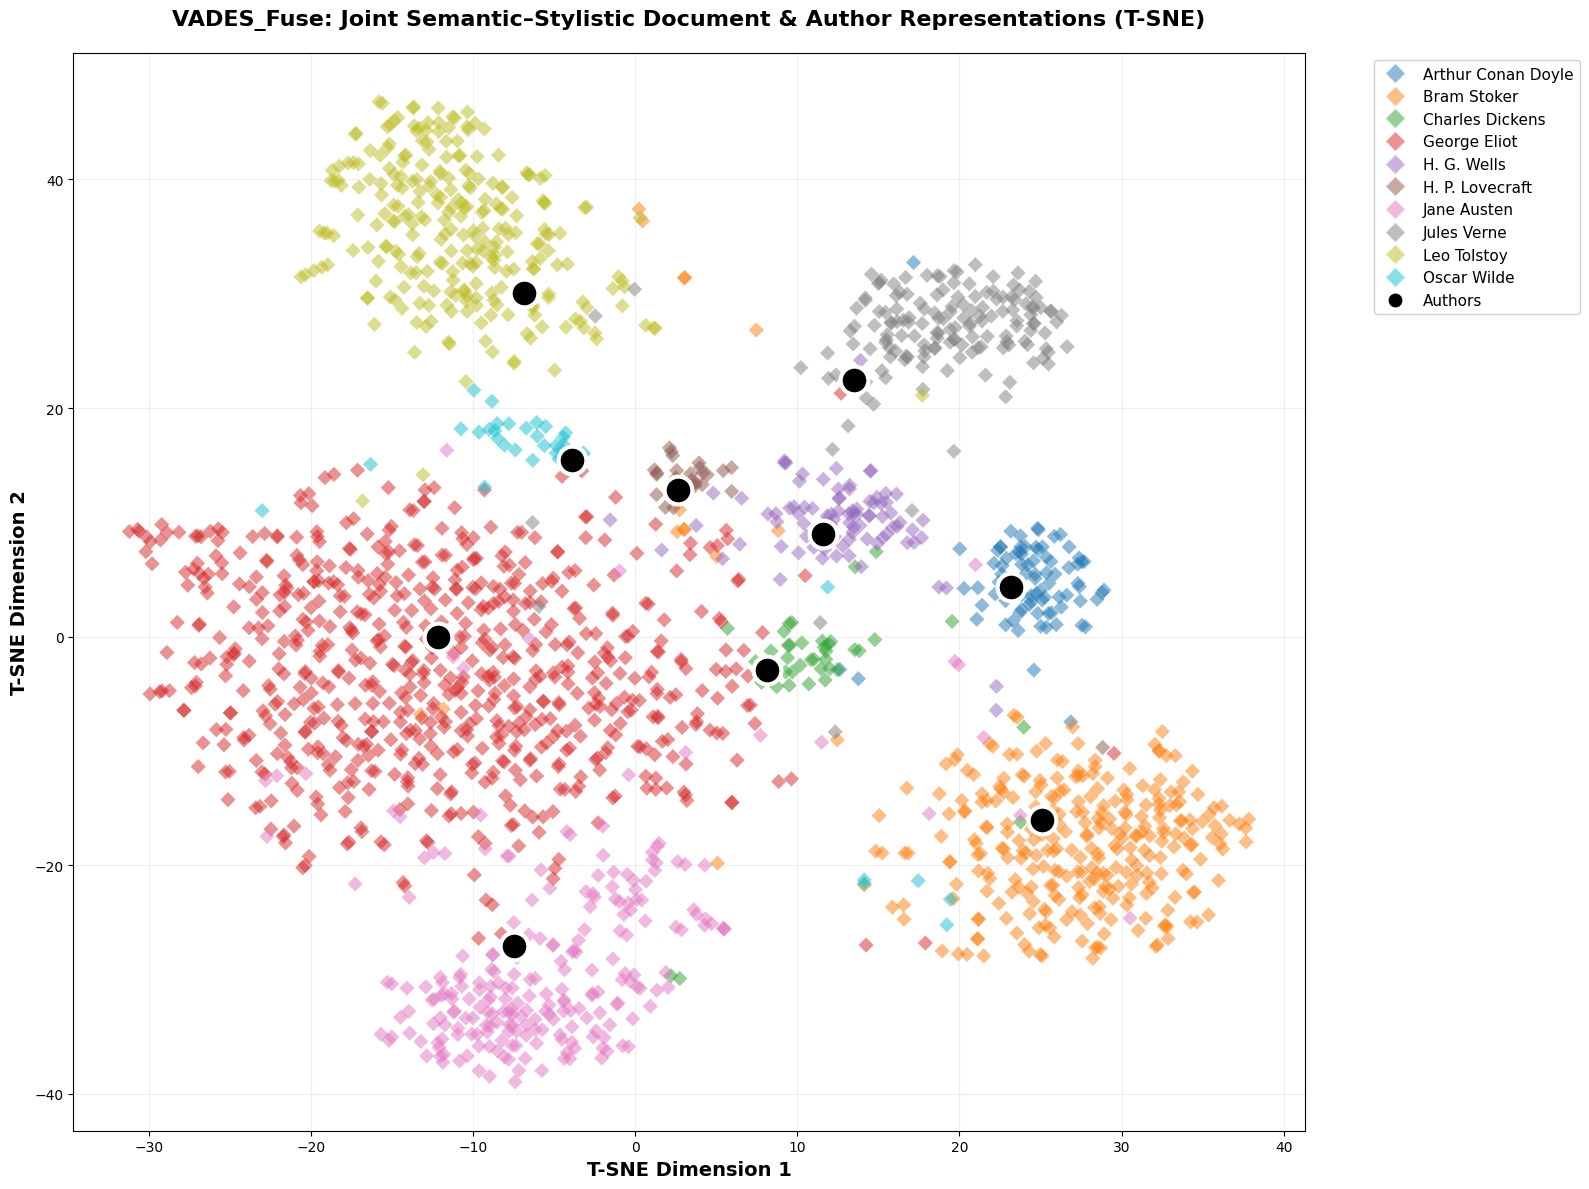

✅ T-SNE visualization (VADES_Fuse) saved!


In [ ]:
# ============================================================================
# VISUALIZATION CELL 2: T-SNE (VADES_Fuse)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



print("\nGenerating T-SNE visualization (VADES_Fuse)...")
model.eval()

# ------------------------------------------------------------
# 1. Extract document embeddings (USE + STYLE → fused embedding)
# ------------------------------------------------------------
test_doc_embeddings = []
test_author_ids = []

with torch.no_grad():
    for use_emb, style_feat, aid in test_loader:
        use_emb = use_emb.to(device)
        style_feat = style_feat.to(device)

        # IMPORTANT: VADES_Fuse needs BOTH inputs
        doc_out = model(use_emb, style_feat)   # [B, out_dim]

        test_doc_embeddings.append(doc_out.cpu().numpy())
        test_author_ids.extend(aid.numpy())

test_doc_embeddings = np.vstack(test_doc_embeddings)  # [N_test, out_dim]

print("✓ Test doc embeddings:", test_doc_embeddings.shape)

# ------------------------------------------------------------
# 2. Get learned author embeddings
# ------------------------------------------------------------
author_embeddings = model.authors.weight.detach().cpu().numpy()  # [num_authors, out_dim]

print("✓ Author embeddings:", author_embeddings.shape)

# ------------------------------------------------------------
# 3. Combine document + author embeddings
# ------------------------------------------------------------
all_embeddings = np.vstack([test_doc_embeddings, author_embeddings])

all_labels = test_author_ids + list(range(num_authors))
all_types = ['document'] * len(test_doc_embeddings) + ['author'] * num_authors

# ------------------------------------------------------------
# 4. Run T-SNE
# ------------------------------------------------------------
print("Applying T-SNE (this may take a minute)...")

tsne = TSNE(
    n_components=2,
    random_state=RND,
    perplexity=30,
    n_iter=1000,
    verbose=1
)

embeddings_2d = tsne.fit_transform(all_embeddings)

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(16, 12))

id2author = {i: a for a, i in author2id.items()}
colors = plt.cm.tab10(np.linspace(0, 1, num_authors))

# ---- Plot documents ----
for i in range(num_authors):
    mask = np.array([
        (label == i and typ == 'document')
        for label, typ in zip(all_labels, all_types)
    ])

    if np.any(mask):
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=[colors[i]],
            alpha=0.5,
            s=60,
            marker='D',
            edgecolors='none',
            label=id2author[i]
        )

# ---- Plot author embeddings ----
author_mask = np.array([typ == 'author' for typ in all_types])
author_indices = np.where(author_mask)[0]

for idx in author_indices:
    plt.scatter(
        embeddings_2d[idx, 0],
        embeddings_2d[idx, 1],
        c='black',
        s=400,
        marker='o',
        edgecolors='white',
        linewidths=3,
        zorder=10
    )

plt.xlabel('T-SNE Dimension 1', fontsize=14, fontweight='bold')
plt.ylabel('T-SNE Dimension 2', fontsize=14, fontweight='bold')
plt.title(
    'VADES_Fuse: Joint Semantic–Stylistic Document & Author Representations (T-SNE)',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Legend
legend_elements = [
    plt.Line2D(
        [0], [0],
        marker='D',
        color='w',
        markerfacecolor=colors[i],
        markersize=10,
        alpha=0.5,
        label=id2author[i]
    )
    for i in range(num_authors)
]
legend_elements.append(
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor='black',
        markersize=12,
        markeredgecolor='white',
        markeredgewidth=2,
        label='Authors'
    )
)

plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    framealpha=0.9
)

plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(
    os.path.join(DRIVE_ROOT, 'tsne_visualization_vades_fuse.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()
print("✅ T-SNE visualization (VADES_Fuse) saved!")



Computing style feature MSE...


Computing test MSE: 100%|██████████| 61/61 [00:00<00:00, 164.59it/s]
/tmp/ipython-input-620270343.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(data_to_plot, labels=['Train', 'Val', 'Test'], patch_artist=True)


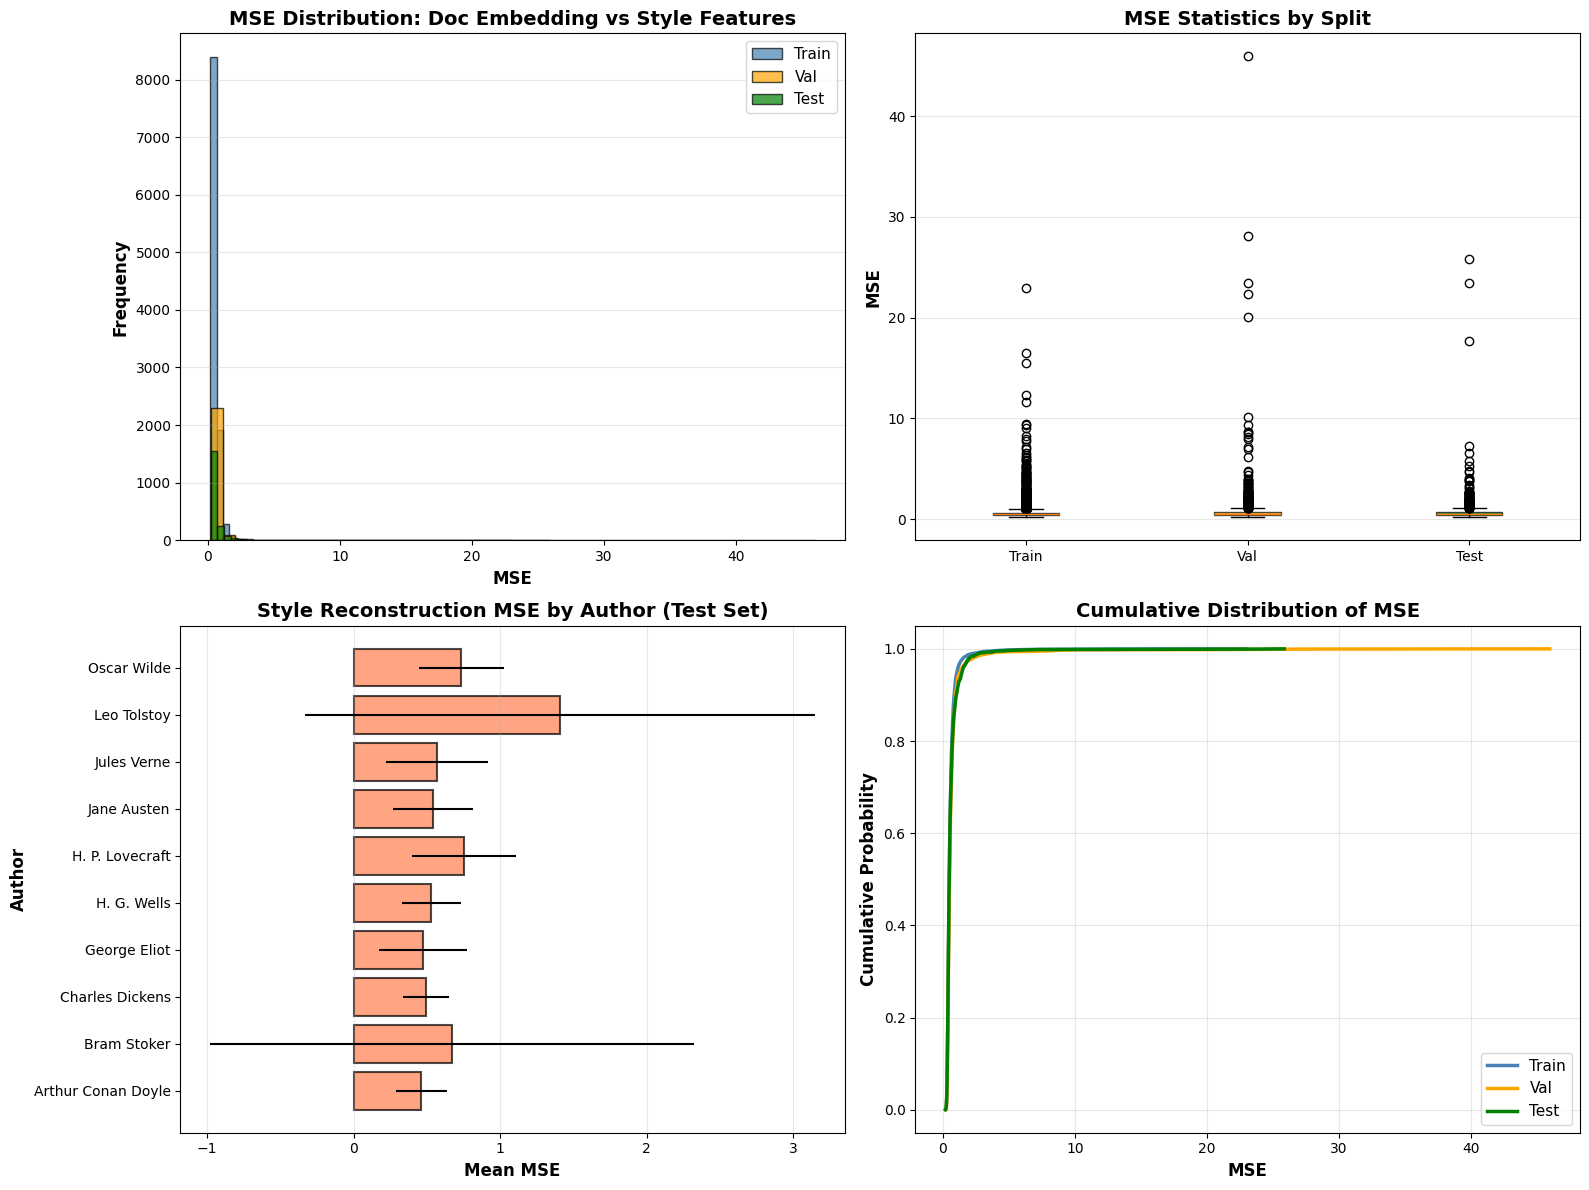


STYLE FEATURE MSE SUMMARY
Train MSE: 0.5912 ± 0.5569
Val MSE:   0.7054 ± 1.4521
Test MSE:  0.6606 ± 0.9970

✅ Style MSE analysis saved!

Generating confusion matrix...


Predicting: 100%|██████████| 61/61 [00:00<00:00, 114.95it/s]


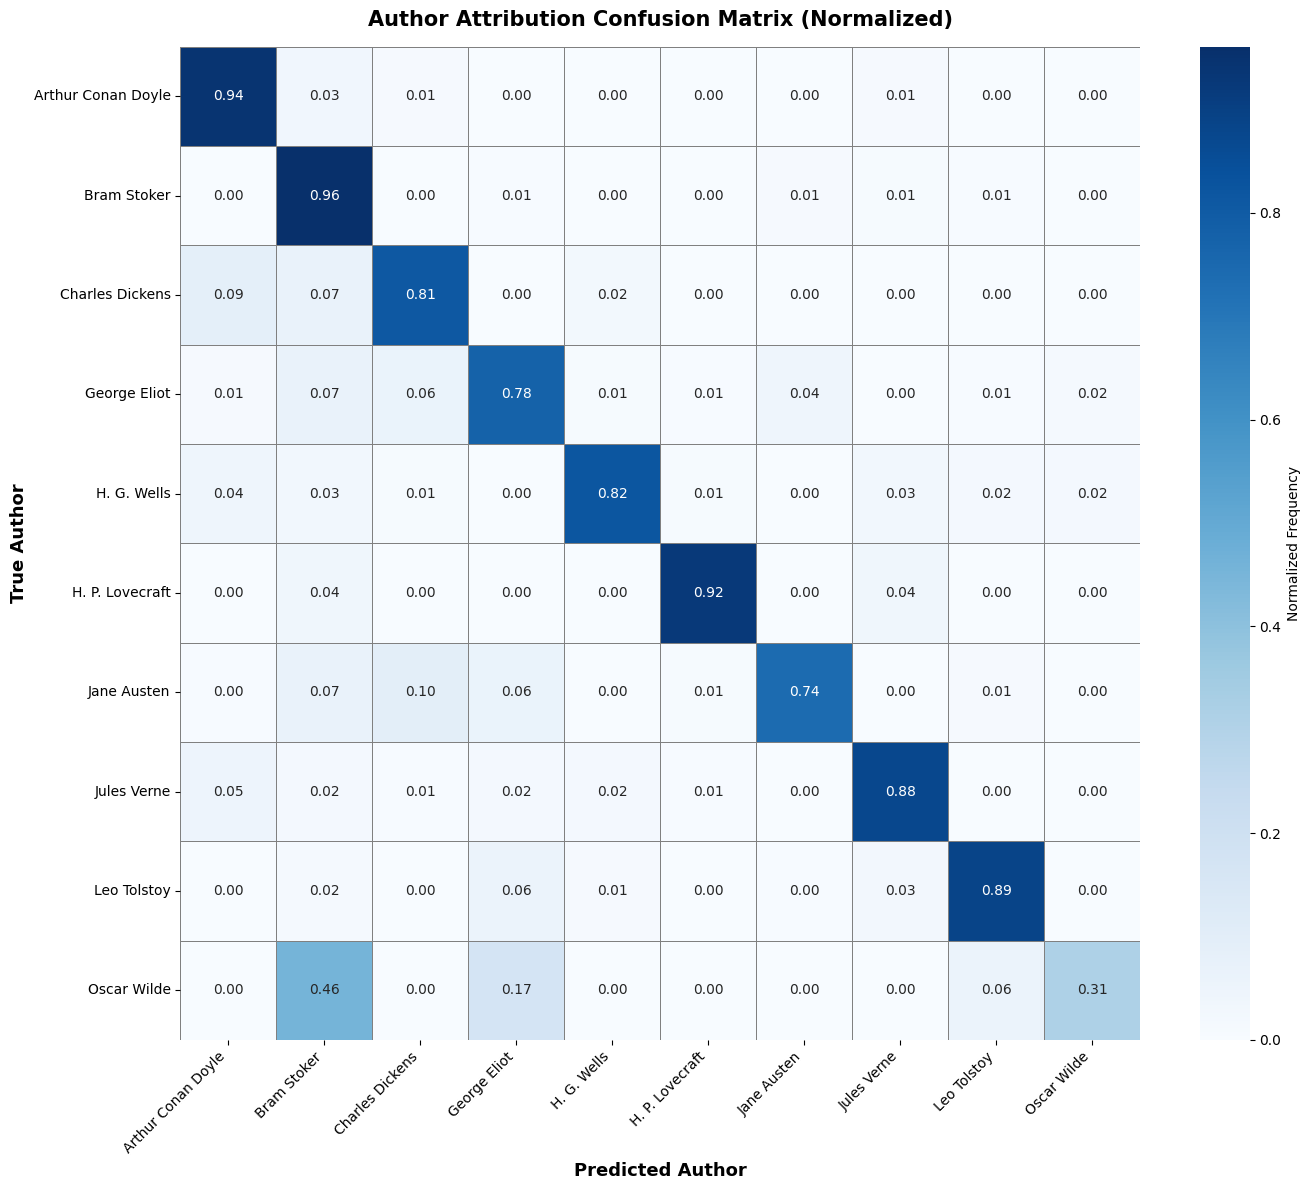


CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Arthur Conan Doyle      0.764     0.942     0.844        86
       Bram Stoker      0.748     0.960     0.841       303
   Charles Dickens      0.337     0.814     0.476        43
      George Eliot      0.929     0.775     0.845       694
       H. G. Wells      0.849     0.820     0.834        89
   H. P. Lovecraft      0.727     0.923     0.814        26
       Jane Austen      0.836     0.742     0.786       240
       Jules Verne      0.888     0.877     0.882       154
       Leo Tolstoy      0.948     0.887     0.916       265
       Oscar Wilde      0.440     0.314     0.367        35

          accuracy                          0.827      1935
         macro avg      0.747     0.805     0.761      1935
      weighted avg      0.853     0.827     0.832      1935


✅ All visualizations complete and saved to Google Drive!

Saved files:
  - /content/drive/MyDrive/final_year_project_books_folder/tra

In [ ]:
# ============================================================================
# VISUALIZATION CELL 3: STYLE FEATURE MSE ANALYSIS
# ============================================================================

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\nComputing style feature MSE...")
model.eval()

train_mse_list = []
val_mse_list = []
test_mse_list = []

with torch.no_grad():
    # Training set
    for doc_emb, style_feat, _ in tqdm(train_loader, desc="Computing train MSE"):
        doc_emb, style_feat = doc_emb.to(device), style_feat.to(device)
        doc_out = model(doc_emb, style_feat) # Corrected: pass both arguments
        mse = torch.mean((doc_out - style_feat) ** 2, dim=1).cpu().numpy()
        train_mse_list.extend(mse)

    # Validation set
    for doc_emb, style_feat, _ in tqdm(val_loader, desc="Computing val MSE"):
        doc_emb, style_feat = doc_emb.to(device), style_feat.to(device)
        doc_out = model(doc_emb, style_feat) # Corrected: pass both arguments
        mse = torch.mean((doc_out - style_feat) ** 2, dim=1).cpu().numpy()
        val_mse_list.extend(mse)

    # Test set
    for doc_emb, style_feat, _ in tqdm(test_loader, desc="Computing test MSE"):
        doc_emb, style_feat = doc_emb.to(device), style_feat.to(device)
        doc_out = model(doc_emb, style_feat) # Corrected: pass both arguments
        mse = torch.mean((doc_out - style_feat) ** 2, dim=1).cpu().numpy()
        test_mse_list.extend(mse)

# Create MSE visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: MSE Distribution (Histogram)
axes[0, 0].hist(train_mse_list, bins=50, alpha=0.7, label='Train', color='steelblue', edgecolor='black')
axes[0, 0].hist(val_mse_list, bins=50, alpha=0.7, label='Val', color='orange', edgecolor='black')
axes[0, 0].hist(test_mse_list, bins=50, alpha=0.7, label='Test', color='green', edgecolor='black')
axes[0, 0].set_xlabel('MSE', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 0].set_title('MSE Distribution: Doc Embedding vs Style Features', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Plot 2: Box Plot Comparison
data_to_plot = [train_mse_list, val_mse_list, test_mse_list]
bp = axes[0, 1].boxplot(data_to_plot, labels=['Train', 'Val', 'Test'], patch_artist=True)
colors_box = ['steelblue', 'orange', 'green']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_ylabel('MSE', fontsize=12, fontweight='bold')
axes[0, 1].set_title('MSE Statistics by Split', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: MSE by Author (Test Set)
test_mse_by_author = defaultdict(list)
idx = 0
for _, _, aid in test_loader:
    for a in aid.numpy():
        if idx < len(test_mse_list):
            test_mse_by_author[a].append(test_mse_list[idx])
            idx += 1

author_names = [id2author[i] for i in range(num_authors)]
author_mse_means = [np.mean(test_mse_by_author[i]) if i in test_mse_by_author else 0
                    for i in range(num_authors)]
author_mse_stds = [np.std(test_mse_by_author[i]) if i in test_mse_by_author else 0
                   for i in range(num_authors)]

axes[1, 0].barh(author_names, author_mse_means, xerr=author_mse_stds,
                color='coral', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_xlabel('Mean MSE', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Author', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Style Reconstruction MSE by Author (Test Set)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Plot 4: Cumulative Distribution
sorted_train = np.sort(train_mse_list)
sorted_val = np.sort(val_mse_list)
sorted_test = np.sort(test_mse_list)

axes[1, 1].plot(sorted_train, np.linspace(0, 1, len(sorted_train)),
                label='Train', linewidth=2.5, color='steelblue')
axes[1, 1].plot(sorted_val, np.linspace(0, 1, len(sorted_val)),
                label='Val', linewidth=2.5, color='orange')
axes[1, 1].plot(sorted_test, np.linspace(0, 1, len(sorted_test)),
                label='Test', linewidth=2.5, color='green')
axes[1, 1].set_xlabel('MSE', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Cumulative Distribution of MSE', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'style_mse_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("STYLE FEATURE MSE SUMMARY")
print("="*80)
print(f"Train MSE: {np.mean(train_mse_list):.4f} ± {np.std(train_mse_list):.4f}")
print(f"Val MSE:   {np.mean(val_mse_list):.4f} ± {np.std(val_mse_list):.4f}")
print(f"Test MSE:  {np.mean(test_mse_list):.4f} ± {np.std(test_mse_list):.4f}")
print("="*80)

print("\n✅ Style MSE analysis saved!")


# ============================================================================
# VISUALIZATION CELL 4: CONFUSION MATRIX
# ============================================================================

print("\nGenerating confusion matrix...")

# Predict on test set
predictions = []
true_labels = []

model.eval()
with torch.no_grad():
    for use_emb, style_feat, aid in tqdm(test_loader, desc="Predicting"):
        use_emb = use_emb.to(device)
        style_feat = style_feat.to(device)
        doc_out = model(use_emb, style_feat).cpu().numpy() # Corrected: pass both arguments

        for i, true_a in enumerate(aid.numpy()):
            dists = {a: np.linalg.norm(doc_out[i] - m) for a, m in author_means.items()}
            pred_a = min(dists, key=dists.get)
            predictions.append(pred_a)
            true_labels.append(true_a)

# Create confusion matrix
cm = confusion_matrix(true_labels, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[id2author[i] for i in range(num_authors)],
            yticklabels=[id2author[i] for i in range(num_authors)],
            cbar_kws={'label': 'Normalized Frequency'},
            linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Author', fontsize=13, fontweight='bold')
plt.ylabel('True Author', fontsize=13, fontweight='bold')
plt.title('Author Attribution Confusion Matrix (Normalized)', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()

# Print classification report
print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(true_labels, predictions,
                           target_names=[id2author[i] for i in range(num_authors)],
                           digits=3))

print("\n✅ All visualizations complete and saved to Google Drive!")
print(f"\nSaved files:")
print(f"  - {os.path.join(DRIVE_ROOT, 'training_losses.png')}")
print(f"  - {os.path.join(DRIVE_ROOT, 'tsne_visualization.png')}")
print(f"  - {os.path.join(DRIVE_ROOT, 'style_mse_analysis.png')}")
print(f"  - {os.path.join(DRIVE_ROOT, 'confusion_matrix.png')}")

In [ ]:
# Safe diagnostic: find 2D numpy arrays in globals and look for candidate embedding files
import numpy as np, glob, os, joblib, pickle

# 1) Snapshot globals and list 2D numpy arrays
g_snapshot = list(globals().items())
candidates = []
for k, v in g_snapshot:
    try:
        if isinstance(v, np.ndarray) and v.ndim == 2:
            candidates.append((k, v.shape))
    except Exception:
        pass

if candidates:
    print("2D NumPy arrays found in globals (name, shape):")
    for name, shape in sorted(candidates, key=lambda x: x[0]):
        print(" ", name, shape)
else:
    print("No 2D NumPy arrays found in globals.")

# 2) Look for embedding-like files in current directory
files = []
for ext in ("*.npy", "*.npz", "*.pkl", "*.joblib", "*.pt", "*.pth"):
    files.extend(glob.glob(ext))
if files:
    print("\nPossible embedding files found in working directory:")
    for f in files:
        try:
            # print file + quick inspect for safe file types
            if f.endswith(".npy"):
                arr = np.load(f, allow_pickle=True)
                print("  ", f, getattr(arr, "shape", None))
            elif f.endswith(".npz"):
                z = np.load(f)
                for k2 in z.files:
                    print("  ", f + ":" + k2, z[k2].shape)
            elif f.endswith(".joblib"):
                try:
                    obj = joblib.load(f)
                    print("  ", f, getattr(obj, "shape", None), type(obj))
                except Exception:
                    print("  ", f, "(joblib load failed)")
            elif f.endswith(".pkl"):
                try:
                    with open(f, "rb") as fh:
                        obj = pickle.load(fh)
                    print("  ", f, getattr(obj, "shape", None), type(obj))
                except Exception:
                    print("  ", f, "(pkl load failed)")
            else:
                print("  ", f)
        except Exception as e:
            print("  ", f, "(inspect failed: {})".format(e))
else:
    print("\nNo typical embedding files (.npy/.npz/.pkl/.joblib/.pt/.pth) found in working directory.")


2D NumPy arrays found in globals (name, shape):
  Y_style (512, 300)
  all_doc_embeddings (15198, 300)
  all_embeddings (1945, 300)
  all_style (15198, 300)
  all_use (15198, 512)
  author_embeddings (10, 300)
  axes (2, 2)
  cm (10, 10)
  cm_normalized (10, 10)
  colors (10, 4)
  doc_embeddings (15173, 300)
  doc_out (15, 300)
  embeddings_2d (1945, 2)
  test_doc_embeddings (1935, 300)
  test_doc_embs (1935, 300)
  test_embeddings (1935, 300)
  test_embs (1935, 512)
  test_feats (1935, 300)
  test_style_feats_array (1935, 300)
  train_doc_embs (10784, 300)
  train_embs (10809, 512)
  train_feats (10809, 300)
  val_doc_embs (2454, 300)
  val_embs (2454, 512)
  val_feats (2454, 300)

No typical embedding files (.npy/.npz/.pkl/.joblib/.pt/.pth) found in working directory.


In [ ]:
# ============================================================================
# CELL: SAVE EMBEDDINGS FOR RECOMMENDER NOTEBOOK
# ============================================================================

import pickle
import joblib

# Create embeddings cache directory
EMBEDDINGS_CACHE_DIR = os.path.join(DRIVE_ROOT, "embeddings_cache")
os.makedirs(EMBEDDINGS_CACHE_DIR, exist_ok=True)

# 1. Save document embeddings
np.save(
    os.path.join(EMBEDDINGS_CACHE_DIR, "all_doc_embeddings.npy"),
    all_doc_embeddings
)
print("✓ Saved all_doc_embeddings.npy")

# 2. Save document authors
np.save(
    os.path.join(EMBEDDINGS_CACHE_DIR, "doc_authors.npy"),
    doc_authors
)
print("✓ Saved doc_authors.npy")

# 3. Save document texts
with open(os.path.join(EMBEDDINGS_CACHE_DIR, "doc_texts.pkl"), "wb") as f:
    pickle.dump(doc_texts, f)
print("✓ Saved doc_texts.pkl")

# 4. Save learned author embeddings
author_embeddings_learned = model.authors.weight.detach().cpu().numpy()
np.save(
    os.path.join(EMBEDDINGS_CACHE_DIR, "author_embeddings.npy"),
    author_embeddings_learned
)
print("✓ Saved author_embeddings.npy")

# 5. Save metadata (mappings and config)
metadata = {
    'author2id': author2id,
    'id2author': id2author,
    'num_authors': num_authors,
    'embed_dim': all_doc_embeddings.shape[1],
    'num_docs': len(all_doc_embeddings),
    'training_date': str(pd.Timestamp.now()),
}

with open(os.path.join(EMBEDDINGS_CACHE_DIR, "metadata.pkl"), "wb") as f:
    pickle.dump(metadata, f)
print("✓ Saved metadata.pkl")

# 6. Save trained model checkpoint (if not already saved)
torch.save(
    model.state_dict(),
    os.path.join(CKPT_DIR, 'vades_final_model.pth')
)
print("✓ Saved final model checkpoint")

print(f"\n{'='*80}")
print("ALL EMBEDDINGS SAVED - Ready for Recommender Notebook")
print(f"{'='*80}")
print(f"Location: {EMBEDDINGS_CACHE_DIR}")
print(f"\nFiles created:")
print(f"  ✓ all_doc_embeddings.npy  [{all_doc_embeddings.shape}]")
print(f"  ✓ doc_authors.npy         [{doc_authors.shape}]")
print(f"  ✓ doc_texts.pkl           [{len(doc_texts)} texts]")
print(f"  ✓ author_embeddings.npy   [{author_embeddings_learned.shape}]")
print(f"  ✓ metadata.pkl")

✓ Saved all_doc_embeddings.npy
✓ Saved doc_authors.npy
✓ Saved doc_texts.pkl
✓ Saved author_embeddings.npy
✓ Saved metadata.pkl
✓ Saved final model checkpoint

ALL EMBEDDINGS SAVED - Ready for Recommender Notebook
Location: /content/drive/MyDrive/final_year_project_books_folder/embeddings_cache

Files created:
  ✓ all_doc_embeddings.npy  [(15198, 300)]
  ✓ doc_authors.npy         [(15198,)]
  ✓ doc_texts.pkl           [15198 texts]
  ✓ author_embeddings.npy   [(10, 300)]
  ✓ metadata.pkl
